## Regression Project

Build a linear regression model that predicts the `price` column in the dataset on San Francisco Apartment rentals. Make sure to go through all the the relevant steps of the modelling workflow.

1. Data Cleaning has already been performed on this data
2. Explore the data, keeping an eye on useful features and potential issues 
3. Choose a model validation scheme (simple or cross validation)
4. Fit a Linear Regression Model
5. Evaluate your model - check assumptions, metrics, and coefficient estimates
6. Engineer Features as needed
7. Repeat Steps 2, 4, 5, 6 as needed
8. Once you are ready, fit your final model and report final model performance estimate by scoring on the test data. Report both test R-squared and MAE.

A reasonable goal is to get a validation MAE of <= 500 dollars.

Advice:

1. "Perfect" is the enemy of "Good".
2. You will not get to an MAE of 0, we don't have perfect data, and there is some randomness and emotion in how things like apartment prices are set. 
3. Modelling is challenging, especially if you're new. There isn't a "right" answer, but some models are better than others. Remember - "All Models are wrong, but some are useful" 
4. We will likely end up with different models and performance metrics, and that's ok. You can always implement new ideas after watching the solution video. I didn't do anything too fancy, so you might think of some great ideas I didn't!
5. Enjoy the process, and remember that at some point it's time to let the model go. No amount of feature engineering will achieve a perfect model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse

rentals_df = pd.read_csv("../Data/sf_clean.csv") 
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0


### Data Dictionary

1. Price: The price of the rental and our target variable
2. sqft: The area in square feet of the rental
3. beds: The number of bedrooms in the rental
4. bath: The number of bathrooms in the rental
5. laundry: Does the rental have a laundry machine inside the house, a shared laundry machine, or no laundry on site?
6. pets: Does the rental allow pets? Cats only, dogs only or both cats and dogs?
7. Housing type: Is the rental in a multi-unit building, a building with two units, or a stand alone house? 
8. Parking: Does the apartment off a parking space? No, protected in a garage, off-street in a parking lot, or valet service?
9. Hood district: Which part of San Francisco is the apartment located?

![image info](SFAR_map.png)

In [2]:
rentals_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          989 non-null    int64  
 1   sqft           989 non-null    float64
 2   beds           989 non-null    float64
 3   bath           989 non-null    float64
 4   laundry        989 non-null    str    
 5   pets           989 non-null    str    
 6   housing_type   989 non-null    str    
 7   parking        989 non-null    str    
 8   hood_district  989 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 69.7 KB


In [3]:
rentals_df.describe()

,price,sqft,beds,bath,hood_district
count,989.000000,989.000000,989.000000,989.000000,989.000000
mean,3595.035389,976.765420,1.679474,1.390293,7.052578
std,1546.222670,474.629798,1.076710,0.562714,2.404716
min,750.000000,150.000000,0.000000,1.000000,1.000000
25%,2650.000000,650.000000,1.000000,1.000000,6.000000
50%,3300.000000,900.000000,2.000000,1.000000,8.000000
75%,4242.000000,1200.000000,2.000000,2.000000,9.000000
max,19000.000000,3500.000000,6.000000,4.000000,10.000000


## EDA


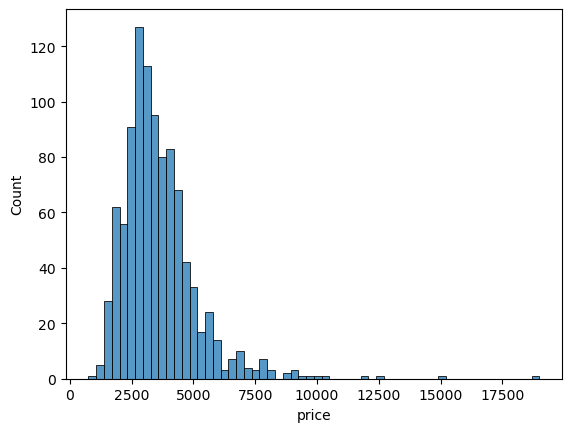

In [4]:
sns.histplot(rentals_df.price);

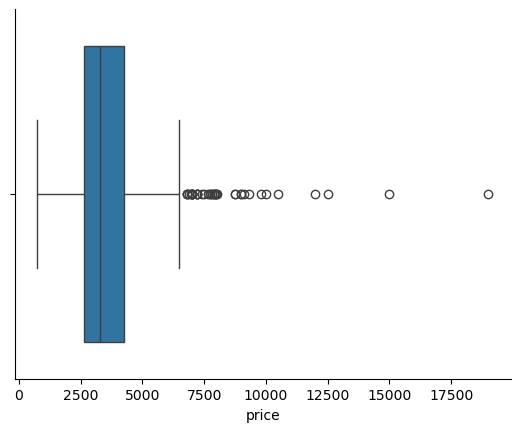

In [5]:
sns.boxplot(x=rentals_df.price);
sns.despine()

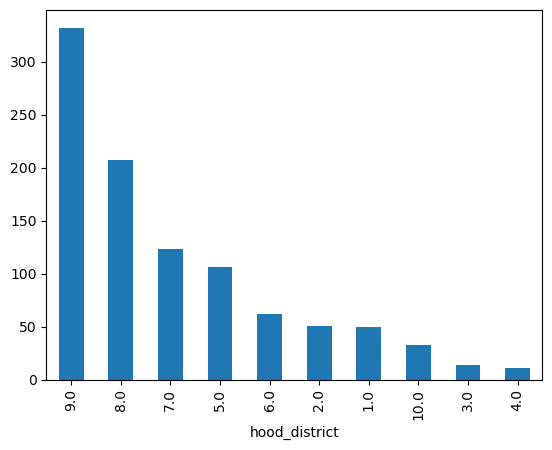

In [6]:
rentals_df.hood_district.value_counts().plot.bar();

In [7]:
rentals_df.hood_district.value_counts()

hood_district
9.0     332
8.0     207
7.0     123
5.0     106
6.0      62
2.0      51
1.0      50
10.0     33
3.0      14
4.0      11
Name: count, dtype: int64

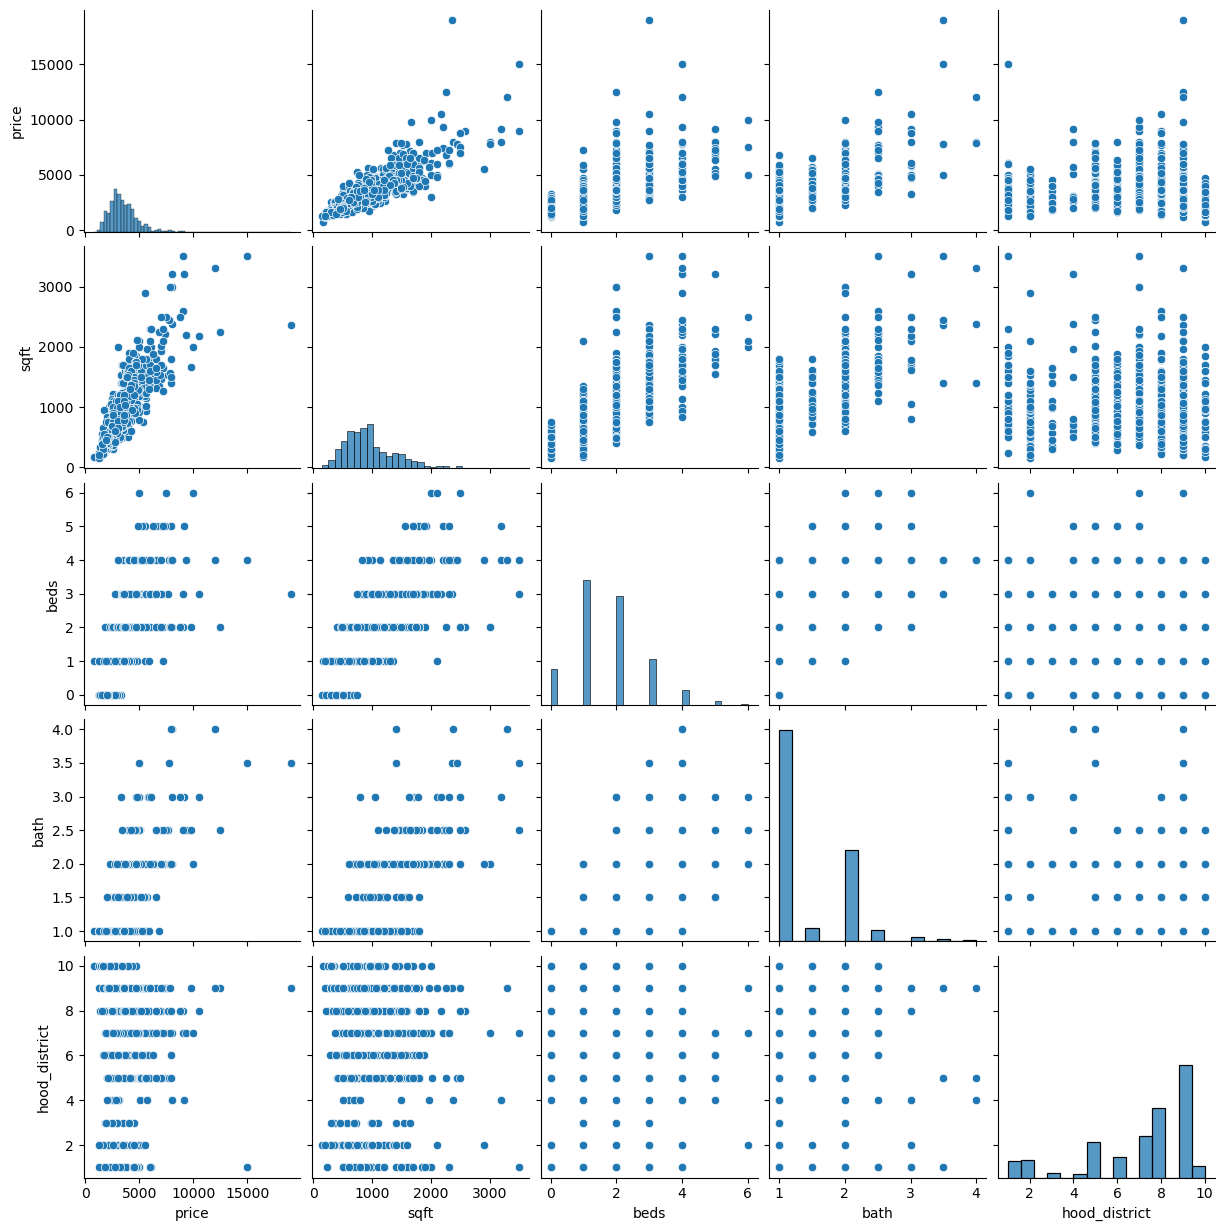

In [8]:
sns.pairplot(rentals_df);

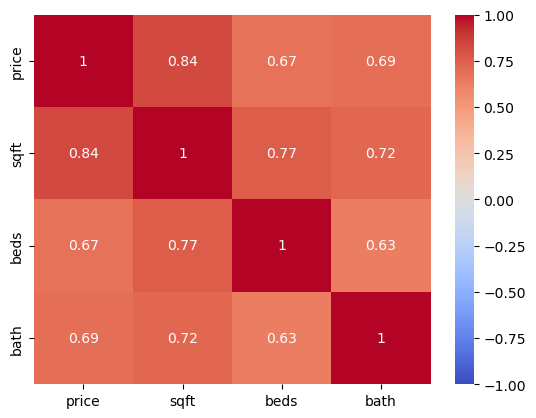

In [9]:
sns.heatmap(rentals_df[['price', 'sqft', 'beds', 'bath']].corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm');

In [10]:
rentals_df.bath.value_counts()

bath
1.0    626
2.0    269
1.5     40
2.5     33
3.0     13
3.5      5
4.0      3
Name: count, dtype: int64

In [11]:
rentals_df.beds.value_counts()

beds
1.0    370
2.0    322
3.0    134
0.0    106
4.0     43
5.0     11
6.0      3
Name: count, dtype: int64

In [12]:
rentals_df.laundry.value_counts()

laundry
(a) in-unit       488
(b) on-site       370
(c) no laundry    131
Name: count, dtype: int64

2.635783250050807


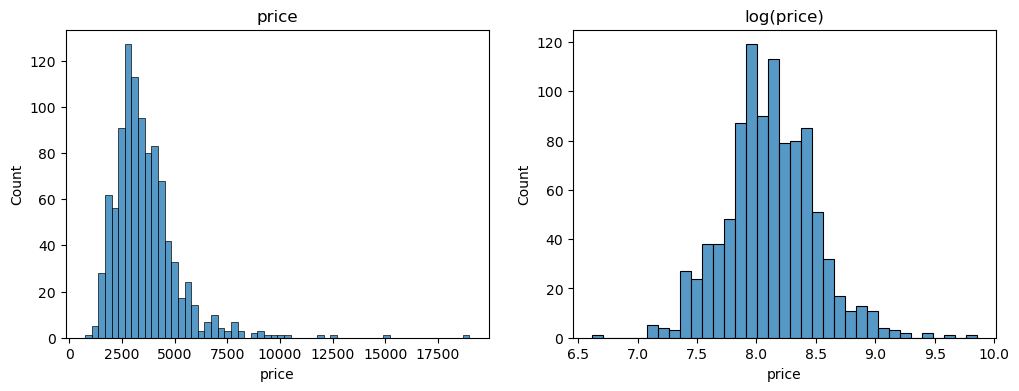

In [13]:
print(rentals_df['price'].skew())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(rentals_df['price'], ax=axes[0]).set_title('price');
sns.histplot(np.log(rentals_df['price']), ax=axes[1]).set_title('log(price)');

## EDA

The `run_eda()` function groups related plots together and can be re-run after 
feature engineering to see how transformations affect the distributions and relationships.

In [14]:
def run_eda(df):
    """
    Exploratory data analysis for the SF rentals dataset.
    Organized into 8 sections. Re-run after feature engineering to 
    compare against the original data.
    """

    numeric_cols = ['sqft', 'beds', 'bath']
    cat_cols     = ['laundry', 'pets', 'housing_type', 'parking']

    # ── 1. Target distribution ────────────────────────────────────────────────
    # Check shape, spread, and whether a log transform improves symmetry.
    # Skew > 1 generally warrants considering log(price) as the target.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Target Variable: Price', fontsize=13)

    sns.histplot(df['price'], ax=axes[0]).set_title('Distribution')
    sns.boxplot(x=df['price'], ax=axes[1]).set_title(f'Boxplot  (skew={df["price"].skew():.2f})')
    sns.despine(ax=axes[1])
    sns.histplot(np.log(df['price']), ax=axes[2]).set_title('log(price)')

    plt.tight_layout()
    plt.show()

    # ── 2. Numeric feature distributions ─────────────────────────────────────
    # Discrete counts for beds/bath reveal sparsity at the extremes (e.g. beds=6).
    # Sparse levels can destabilize coefficients and may need to be collapsed.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Numeric Feature Distributions', fontsize=13)

    for ax, col in zip(axes, numeric_cols):
        df[col].value_counts().sort_index().plot.bar(ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.show()

    # ── 3. Numeric features vs price ─────────────────────────────────────────
    # regplot overlays a fitted line + confidence band, giving an early read on
    # linearity. Systematic curve = consider a transform or polynomial term.
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Numeric Features vs Price', fontsize=13)

    for ax, col in zip(axes, numeric_cols):
        sns.regplot(x=col, y='price', data=df, ax=ax, scatter_kws={'alpha': 0.3})
        ax.set_title(f'{col} vs price')

    plt.tight_layout()
    plt.show()

    # ── 4. sqft vs price by categorical hue ──────────────────────────────────
    # If slopes diverge across categories, an interaction term may improve the
    # model. Parallel slopes = additive effect only, no interaction needed.
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('sqft vs price — by Category', fontsize=13)

    for ax, hue in zip(axes.flatten(), cat_cols):
        for level in df[hue].unique():
            subset = df[df[hue] == level]
            sns.regplot(x='sqft', y='price', data=subset, ax=ax,
                        label=level,
                        scatter_kws={'alpha': 0.15},
                        line_kws={'linewidth': 2})
        ax.set_title(f'sqft vs price  |  hue: {hue}')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # ── 4b. beds and bath vs price by categorical hue ─────────────────────────
    # All categoricals × both predictors. Let the plots tell you what interacts,
    # don't assume in advance.
    fig, axes = plt.subplots(4, 2, figsize=(14, 20))
    fig.suptitle('beds & bath vs price — by Category', fontsize=13)

    combos = [(pred, hue) for hue in cat_cols for pred in ['beds', 'bath']]

    for ax, (pred, hue) in zip(axes.flatten(), combos):
        for level in df[hue].unique():
            subset = df[df[hue] == level]
            sns.regplot(x=pred, y='price', data=subset, ax=ax,
                        label=level,
                        scatter_kws={'alpha': 0.15},
                        line_kws={'linewidth': 2})
        ax.set_title(f'{pred} vs price  |  hue: {hue}')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

    # ── 5. Categorical feature distributions ─────────────────────────────────
    # Check class balance. Heavily imbalanced categories may have unreliable
    # coefficient estimates after one-hot encoding.
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Categorical Feature Distributions', fontsize=13)

    for ax, col in zip(axes.flatten(), cat_cols):
        df[col].value_counts().plot.bar(ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    # ── 6. Categorical features vs price ─────────────────────────────────────
    # Boxplots show whether price meaningfully differs across categories.
    # Overlapping boxes = weak predictor. Clear separation = useful feature.
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for ax, col in zip(axes.flatten(), cat_cols):
        df.boxplot(column='price', by=col, ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('Categorical Features vs Price', fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── 7. Hood district ──────────────────────────────────────────────────────
    # Districts 3 and 4 have very few observations — treat hood_district as 
    # categorical (not numeric) to avoid imposing a false linear ordering.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Hood District', fontsize=13)

    df['hood_district'].value_counts().sort_index().plot.bar(ax=axes[0])
    axes[0].set_title('Count per District')

    df.boxplot(column='price', by='hood_district', ax=axes[1])
    axes[1].set_title('Price by District')

    plt.suptitle('')
    plt.tight_layout()
    plt.show()

    # ── 8. Numeric correlation matrix ────────────────────────────────────────
    # High correlation between predictors (multicollinearity) inflates standard
    # errors on OLS coefficients. beds and sqft are likely correlated — check.
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        df[['price', 'sqft', 'beds', 'bath']].corr(),
        annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='coolwarm', ax=ax
    )
    ax.set_title('Numeric Correlation Matrix')
    plt.tight_layout()
    plt.show()

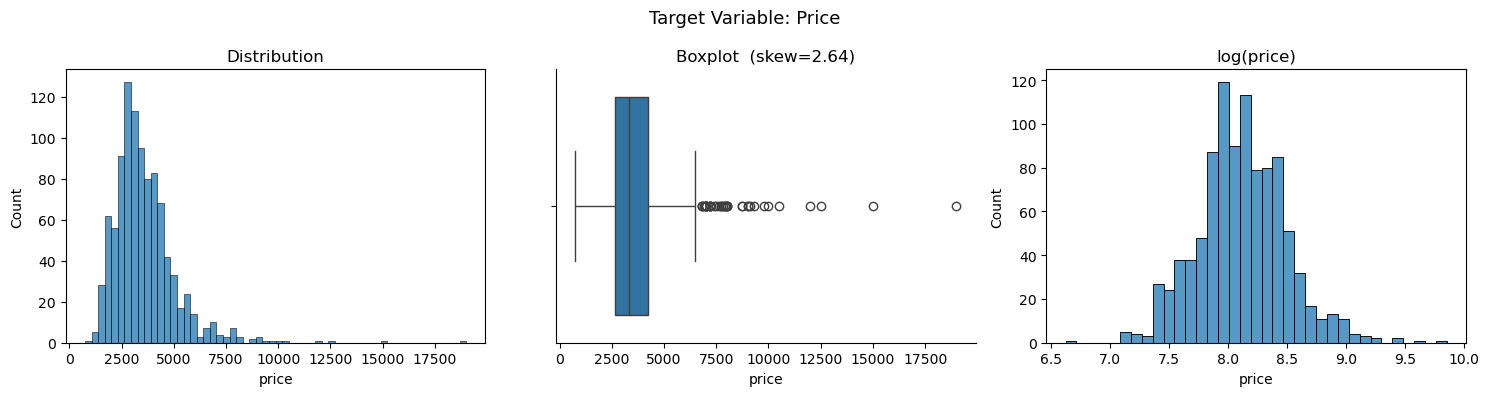

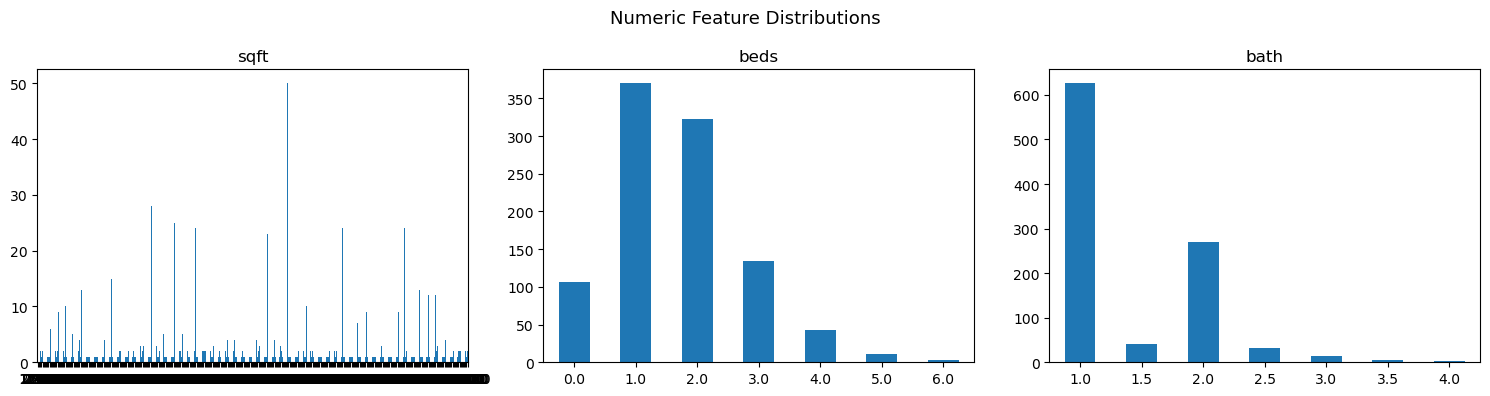

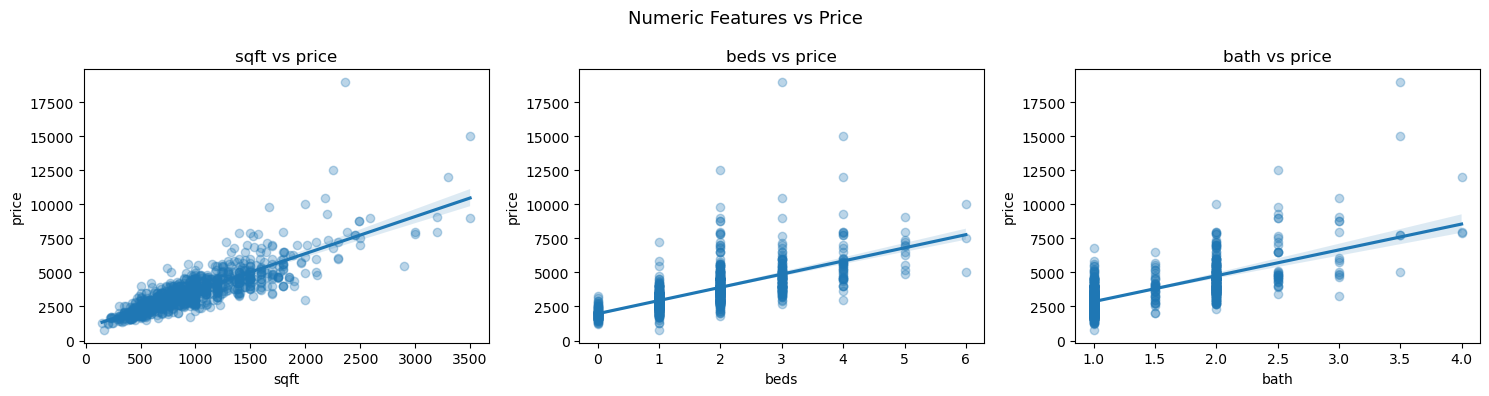

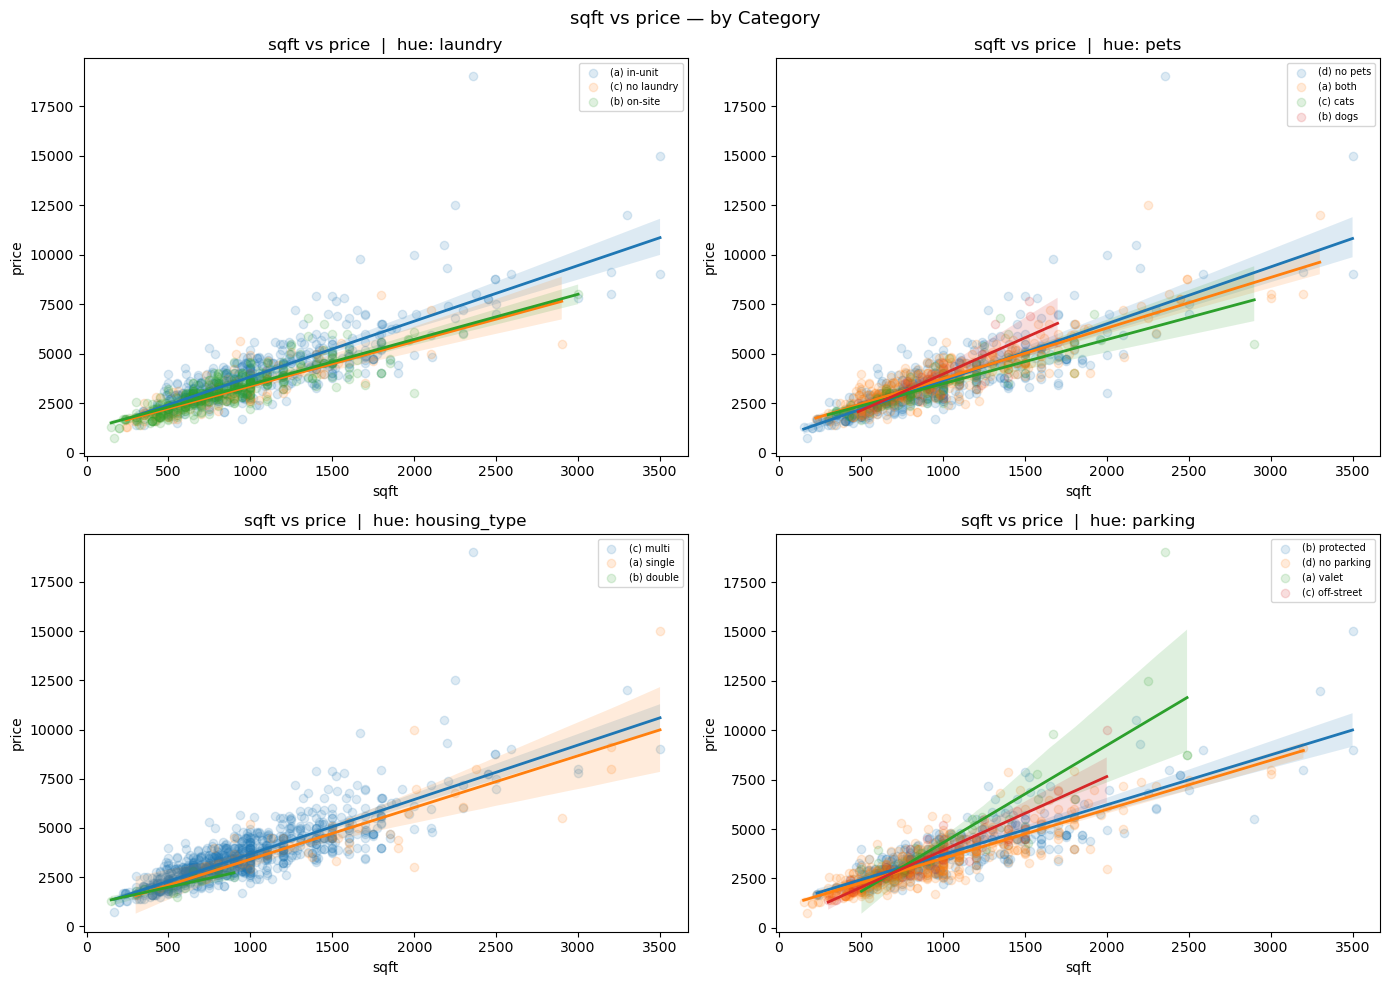

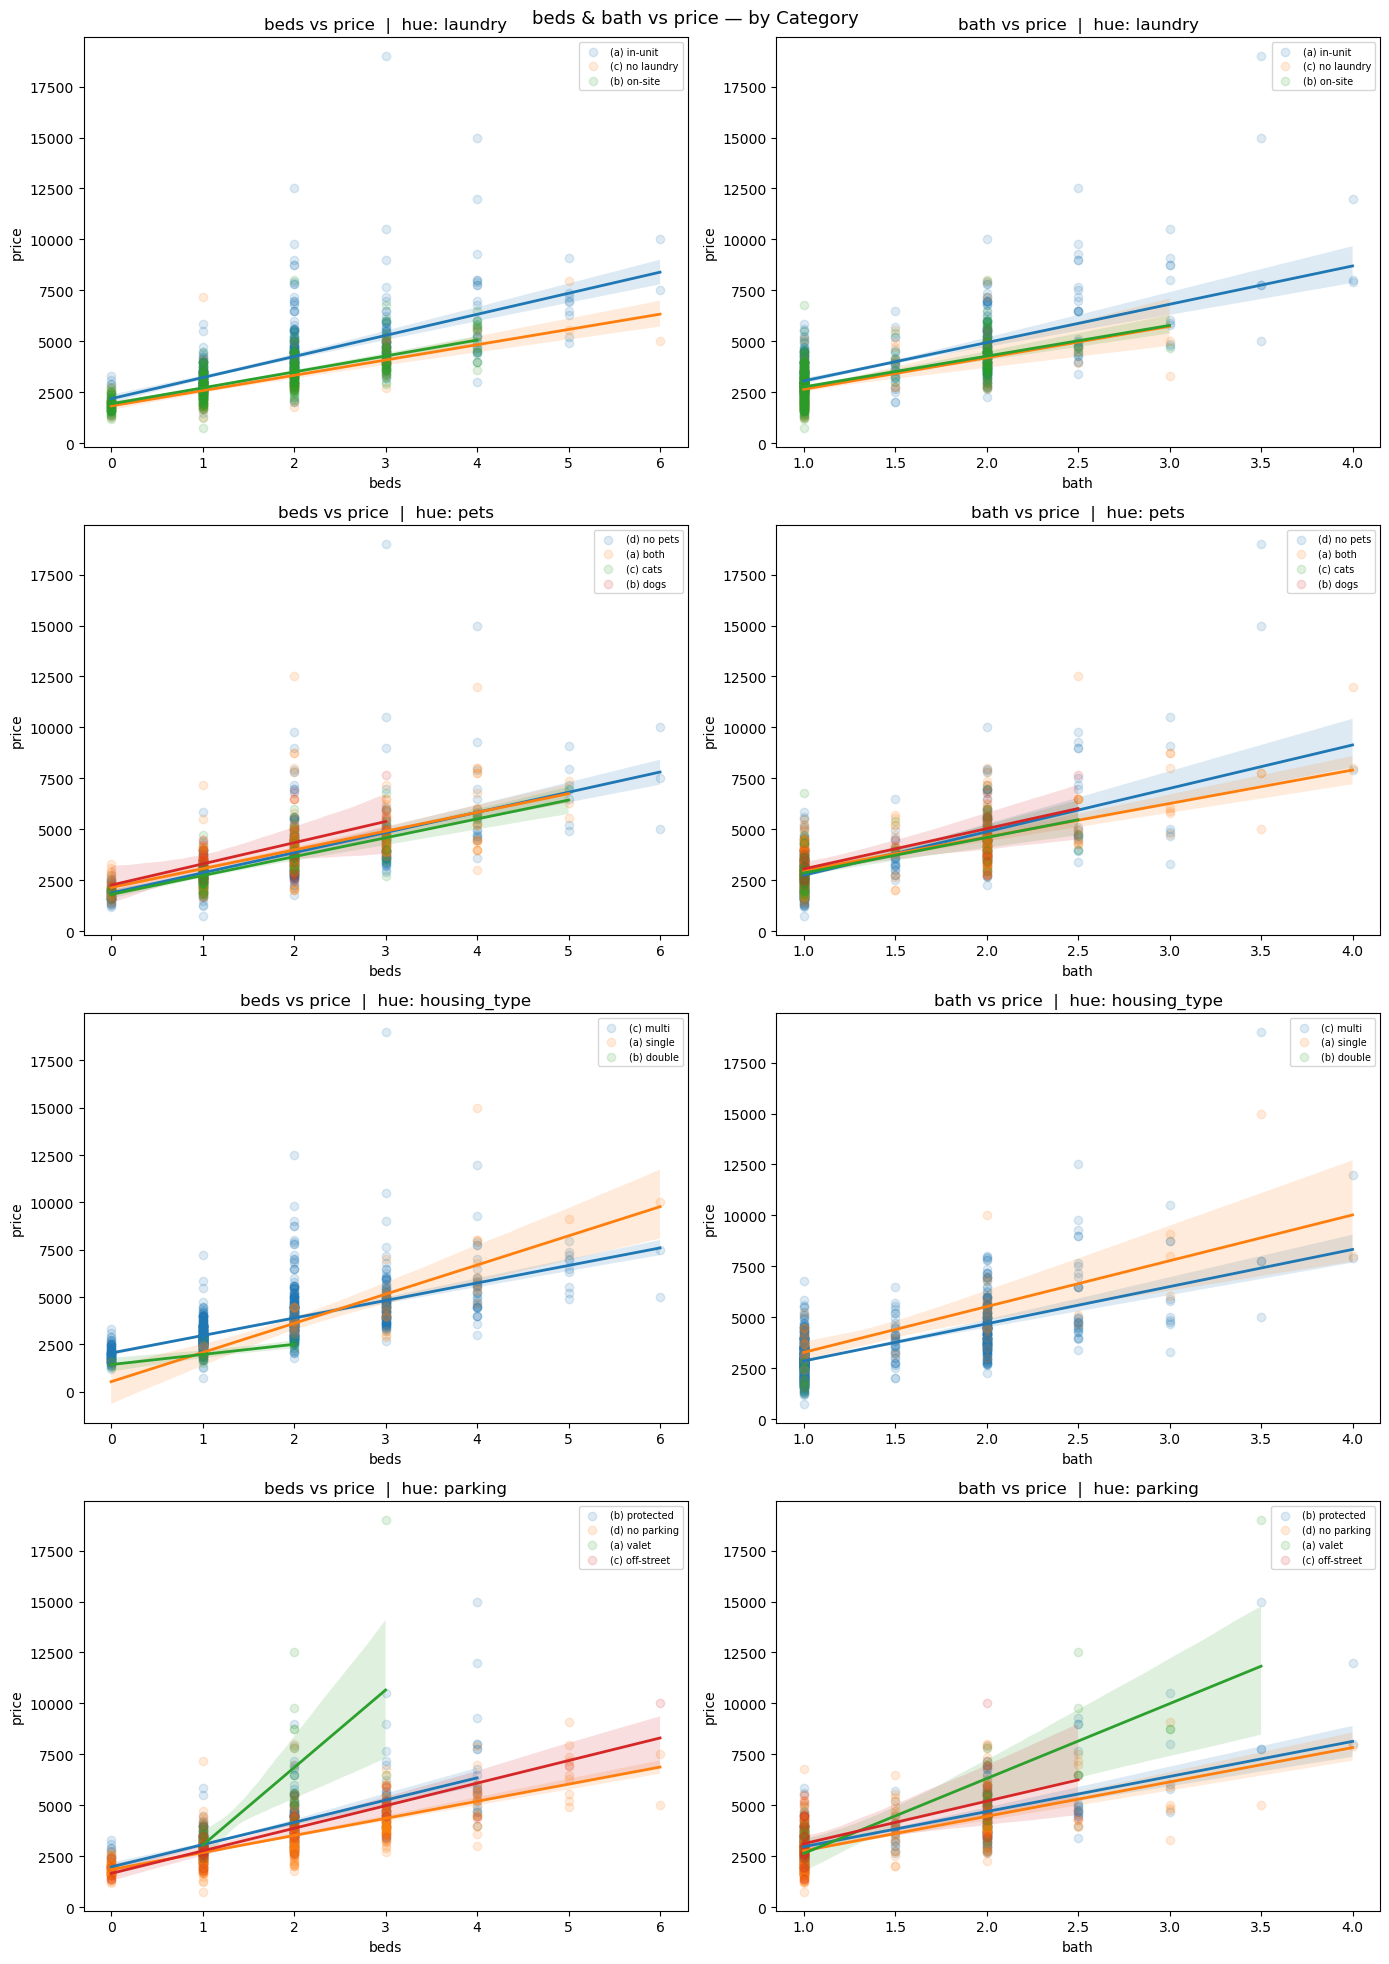

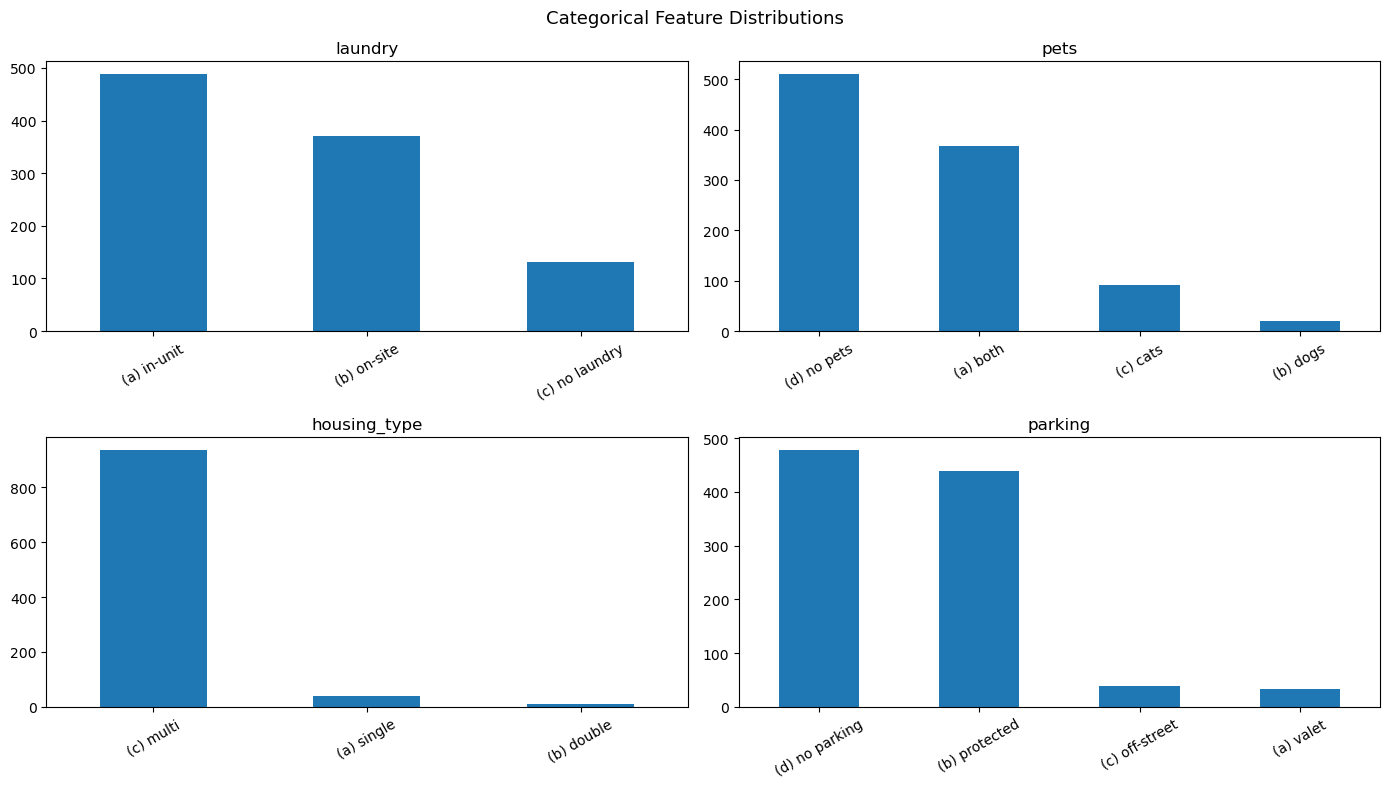

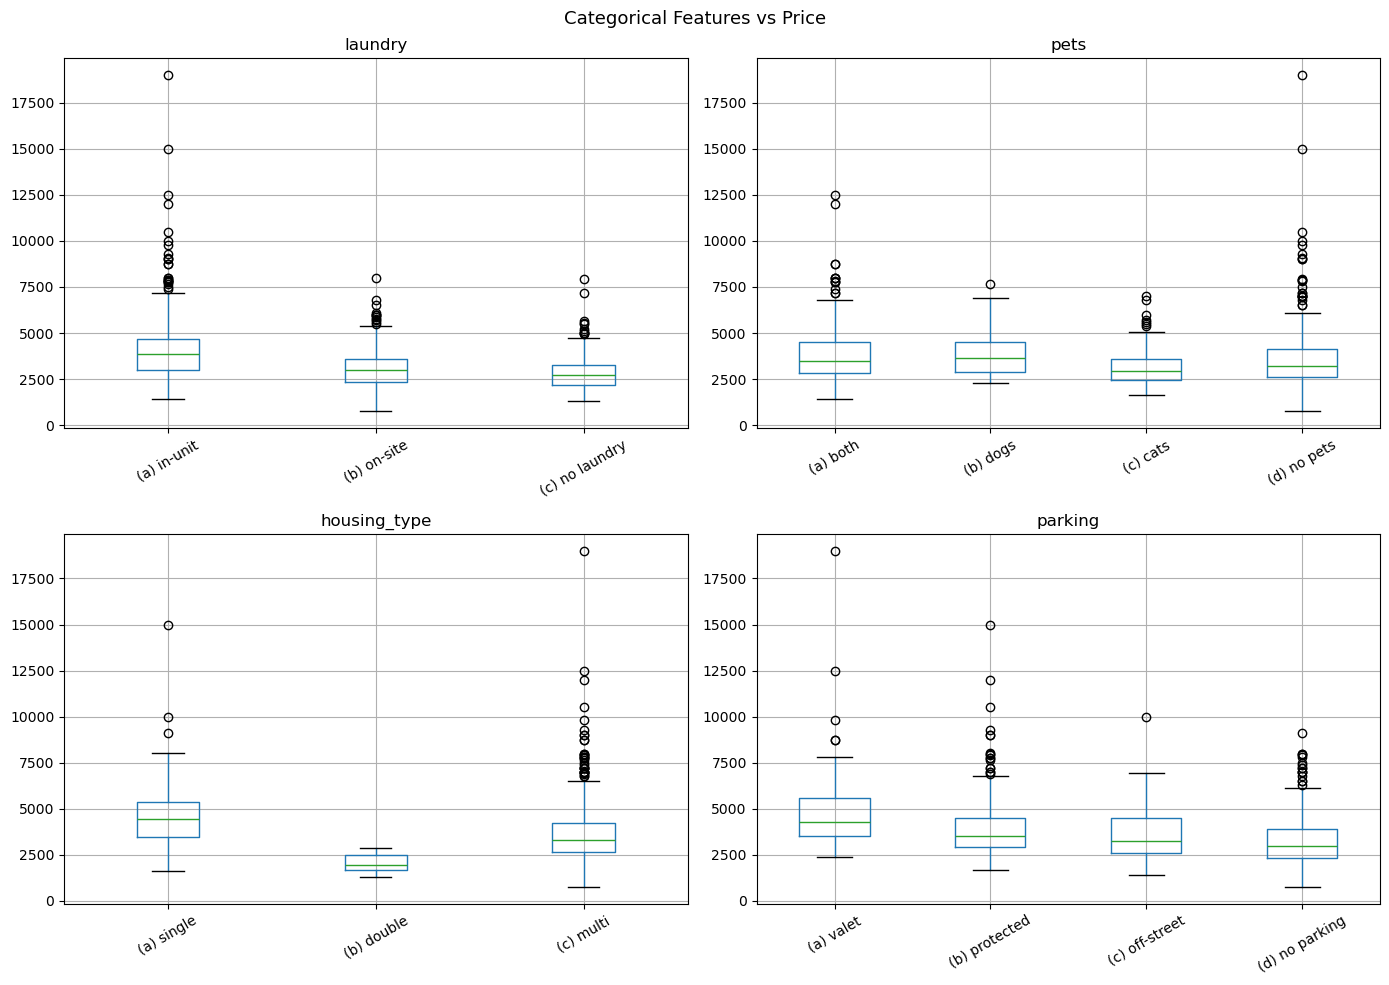

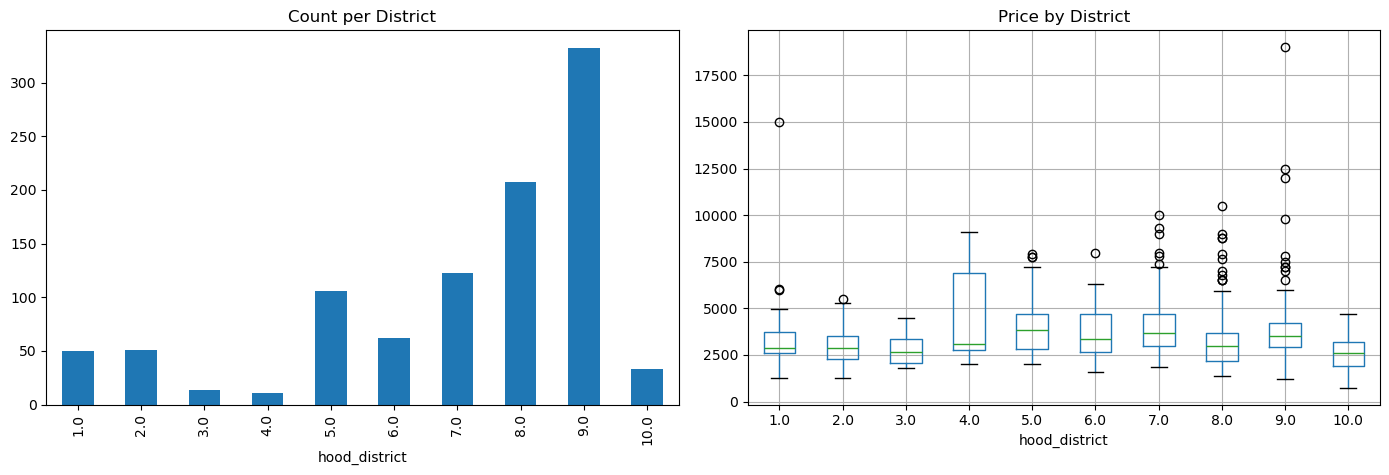

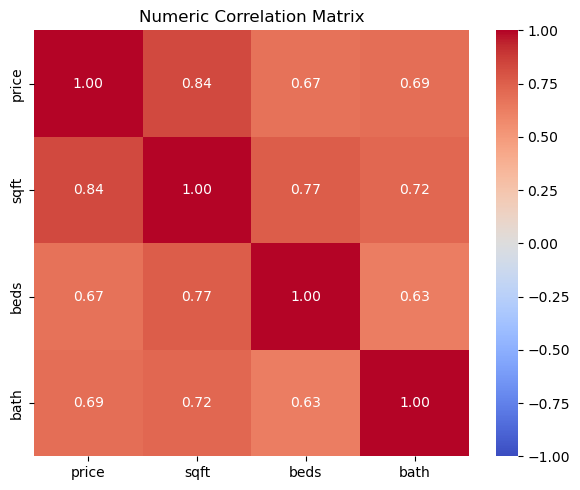

In [15]:
run_eda(rentals_df)

## Feature Engineering


In [16]:
zone_map = {
    1: 'west',     # Northwest — low/mid price, western corridor
    2: 'west',     # Central West
    3: 'west',     # Southwest
    4: 'central',  # Twin Peaks — sparse, geographically central
    5: 'central',  # Central
    6: 'central',  # Central North
    7: 'north',    # North
    8: 'north',    # Northeast
    9: 'east',     # Central East — clearly distinct pricing
    10: 'south',   # Southeast — sparse, keep separate from west given geography
}

rentals_df['district_zone'] = rentals_df['hood_district'].map(zone_map)
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,north
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,north
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,north


In [17]:
# Collapse the three parallel categories — their slopes are identical
# across sqft, beds, and bath in every plot
rentals_df['is_valet'] = (rentals_df['parking'] == '(a) valet').astype(int)
rentals_df['valet_x_sqft'] = rentals_df['is_valet'] * rentals_df['sqft']
rentals_df['valet_x_beds'] = rentals_df['is_valet'] * rentals_df['beds']
rentals_df['valet_x_bath'] = rentals_df['is_valet'] * rentals_df['bath']

rentals_df['has_parking']   = (rentals_df['parking'] != '(d) no parking').astype(int)

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0


In [18]:
rentals_df['in_unit_laundry'] = np.where(rentals_df.laundry == '(a) in-unit', 1, 0)
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,in_unit_laundry
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0,1
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0,0


In [19]:
# Single family homes price-per-bedroom/bathroom differently than multi-unit
rentals_df['is_single'] = (rentals_df['housing_type'] == '(a) single').astype(int)

rentals_df['single_x_beds'] = rentals_df['is_single'] * rentals_df['beds']
rentals_df['single_x_bath'] = rentals_df['is_single'] * rentals_df['bath']

rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,in_unit_laundry,is_single,single_x_beds,single_x_bath
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0,1,0,0.0,0.0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0,0,0,0.0,0.0


In [20]:
rentals_df['allows_dogs'] = rentals_df['pets'].isin(['(a) both', '(b) dogs']).astype(int)
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,in_unit_laundry,is_single,single_x_beds,single_x_bath,allows_dogs
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0,0
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0,1
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0,1,0,0.0,0.0,1
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0,0
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,north,0,0.0,0.0,0.0,0,0,0,0.0,0.0,1


In [21]:
rentals_df['is_double'] = (rentals_df['housing_type'] == '(b) double').astype(int)
rentals_df.head()

,price,sqft,beds,bath,laundry,pets,housing_type,parking,hood_district,district_zone,...,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,in_unit_laundry,is_single,single_x_beds,single_x_bath,allows_dogs,is_double
0,6800,1600.0,2.0,2.0,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,...,0.0,0.0,0.0,1,1,0,0.0,0.0,0,0
1,3500,550.0,1.0,1.0,(a) in-unit,(a) both,(c) multi,(b) protected,7.0,north,...,0.0,0.0,0.0,1,1,0,0.0,0.0,1,0
2,5100,1300.0,2.0,1.0,(a) in-unit,(a) both,(c) multi,(d) no parking,7.0,north,...,0.0,0.0,0.0,0,1,0,0.0,0.0,1,0
3,9000,3500.0,3.0,2.5,(a) in-unit,(d) no pets,(c) multi,(b) protected,7.0,north,...,0.0,0.0,0.0,1,1,0,0.0,0.0,0,0
4,3100,561.0,1.0,1.0,(c) no laundry,(a) both,(c) multi,(d) no parking,7.0,north,...,0.0,0.0,0.0,0,0,0,0.0,0.0,1,0


In [22]:
rentals_df.drop(columns=['hood_district', 'parking', 'laundry', 'pets','housing_type'], inplace = True)
rentals_df.head()

,price,sqft,beds,bath,district_zone,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,in_unit_laundry,is_single,single_x_beds,single_x_bath,allows_dogs,is_double
0,6800,1600.0,2.0,2.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0,0,0
1,3500,550.0,1.0,1.0,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0,1,0
2,5100,1300.0,2.0,1.0,north,0,0.0,0.0,0.0,0,1,0,0.0,0.0,1,0
3,9000,3500.0,3.0,2.5,north,0,0.0,0.0,0.0,1,1,0,0.0,0.0,0,0
4,3100,561.0,1.0,1.0,north,0,0.0,0.0,0.0,0,0,0,0.0,0.0,1,0


In [23]:
rentals_df = pd.get_dummies(rentals_df, drop_first=True, dtype=int)
rentals_df.head()

,price,sqft,beds,bath,is_valet,valet_x_sqft,valet_x_beds,valet_x_bath,has_parking,in_unit_laundry,is_single,single_x_beds,single_x_bath,allows_dogs,is_double,district_zone_east,district_zone_north,district_zone_south,district_zone_west
0,6800,1600.0,2.0,2.0,0,0.0,0.0,0.0,1,1,0,0.0,0.0,0,0,0,1,0,0
1,3500,550.0,1.0,1.0,0,0.0,0.0,0.0,1,1,0,0.0,0.0,1,0,0,1,0,0
2,5100,1300.0,2.0,1.0,0,0.0,0.0,0.0,0,1,0,0.0,0.0,1,0,0,1,0,0
3,9000,3500.0,3.0,2.5,0,0.0,0.0,0.0,1,1,0,0.0,0.0,0,0,0,1,0,0
4,3100,561.0,1.0,1.0,0,0.0,0.0,0.0,0,0,0,0.0,0.0,1,0,0,1,0,0


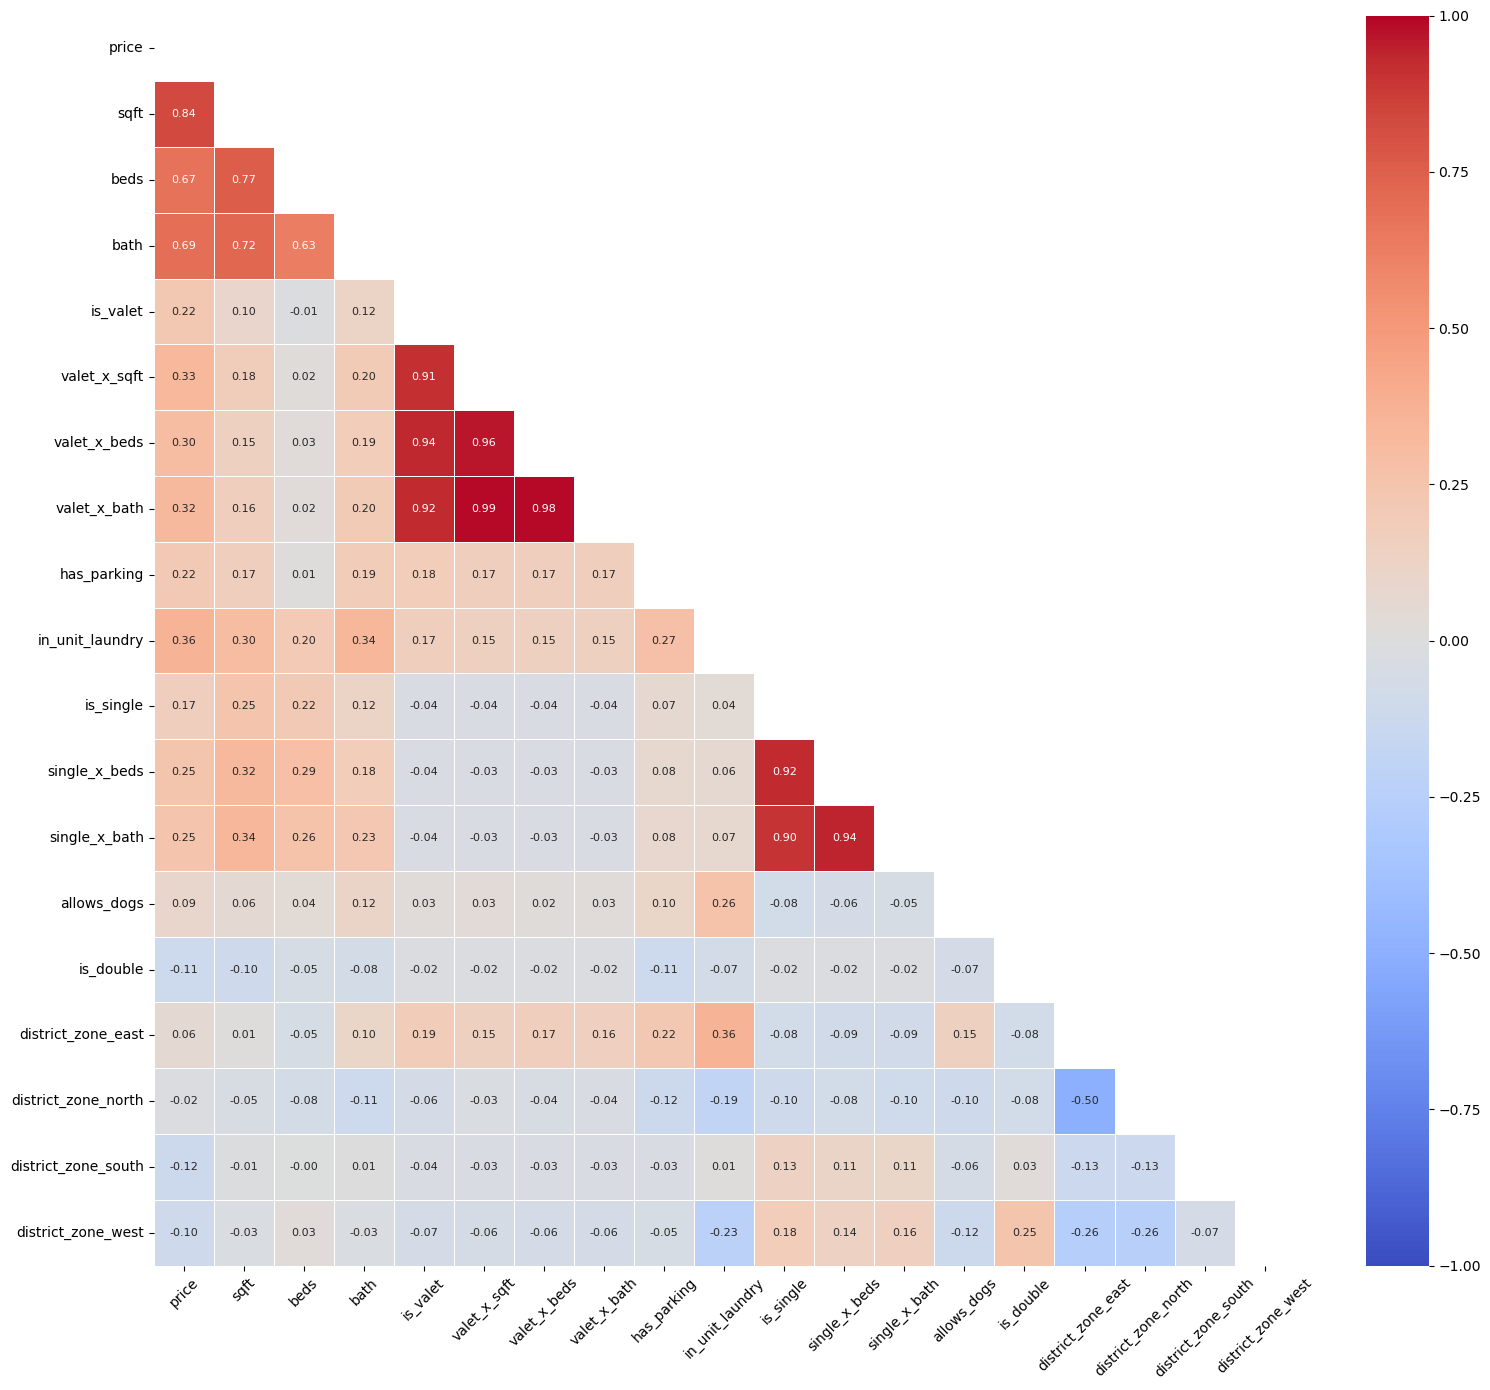

In [24]:
fig, ax = plt.subplots(figsize=(16, 14))

mask = np.triu(np.ones_like(rentals_df.corr(), dtype=bool))  # hide upper triangle — it's redundant

sns.heatmap(
    rentals_df.corr(),
    annot=True, fmt='.2f',
    vmin=-1, vmax=1, cmap='coolwarm',
    mask=mask,
    annot_kws={'size': 8},
    linewidths=0.5,
    ax=ax
);
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## Data Splitting

In [25]:
def split_data(df, features):
    from sklearn.model_selection import train_test_split
    
    X = sm.add_constant(df[features])
    y = np.log(df["price"])
    
    # Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
    print(
        f'Training Set Rows: {X.shape[0]}',
        f'Test Set Rows: {X_test.shape[0]}'
    )

    return X_train, X_test, y_train, y_test

In [26]:
features = ['sqft', 'beds', 'bath']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)

Training Set Rows: 989 Test Set Rows: 198


## Model Fitting & Validation Scoring

In [27]:
def cv(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    cv_r2s, cv_maes, cv_mses = [], [], []
    
    for train_ind, val_ind in kf.split(X, y):
        X_train, y_train = X.iloc[train_ind], y.iloc[train_ind]
        X_val, y_val     = X.iloc[val_ind],   y.iloc[val_ind]
    
        model = sm.OLS(y_train, X_train).fit()
        preds = model.predict(X_val)

        cv_r2s.append(r2(y_val, preds))
        cv_maes.append(mae(np.exp(y_val), np.exp(preds)))
        cv_mses.append(mse(np.exp(y_val), np.exp(preds)))

    print('All Validation R2:  ', [round(x, 3) for x in cv_r2s])
    print(f'R2:  {round(np.mean(cv_r2s), 3)} +- {round(np.std(cv_r2s), 3)}')
    print(f'MAE: {round(np.mean(cv_maes), 3)} +- {round(np.std(cv_maes), 3)}')
    print(f'MSE: {round(np.mean(cv_mses), 3)} +- {round(np.std(cv_mses), 3)}')

    return model

In [28]:
def residual_analysis_plots(model):
    
    import scipy.stats as stats
    import matplotlib.pyplot as plt
    
    predictions = model.predict()
    residuals = model.resid
    
    fig, ax = plt.subplots(1, 2, sharey="all", figsize=(10, 6))
    
    sns.scatterplot(x=predictions, y=residuals, ax=ax[0], alpha=.3)
    ax[0].set_title("Residual Plot")
    ax[0].set_xlabel("Prediction")
    ax[0].set_ylabel("Residuals")
    
    stats.probplot(residuals, dist="norm", plot=ax[1])
    ax[1].set_title("Normal Q-Q Plot")   


In [29]:
model = cv(X_train, y_train)

All Validation R2:   [0.736, 0.667, 0.779, 0.749, 0.751]
R2:  0.736 +- 0.037
MAE: 557.004 +- 60.775
MSE: 787155.629 +- 306024.704


## Assumptions Checking

In [30]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     606.4
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.14e-185
Time:                        21:49:06   Log-Likelihood:                 145.48
No. Observations:                 633   AIC:                            -283.0
Df Residuals:                     629   BIC:                            -265.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.4156      0.021    353.006      0.000       7.374       7.457
sqft           0.0005   2.93e-05     16.191      0.000       0.000       0.001
beds           0.0723      0.011      6.447      0.000       0.050       0.094
bath           0.0769      0.020      3.784      0.000       0.037       0.117
==============================================================================
Omnibus:                       33.970   Durbin-Watson:                   2.125
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               58.588
Skew:                          -0.381   Prob(JB):                     1.90e-13
Kurtosis:                       4.281   Cond. No.                     3.69e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.69e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

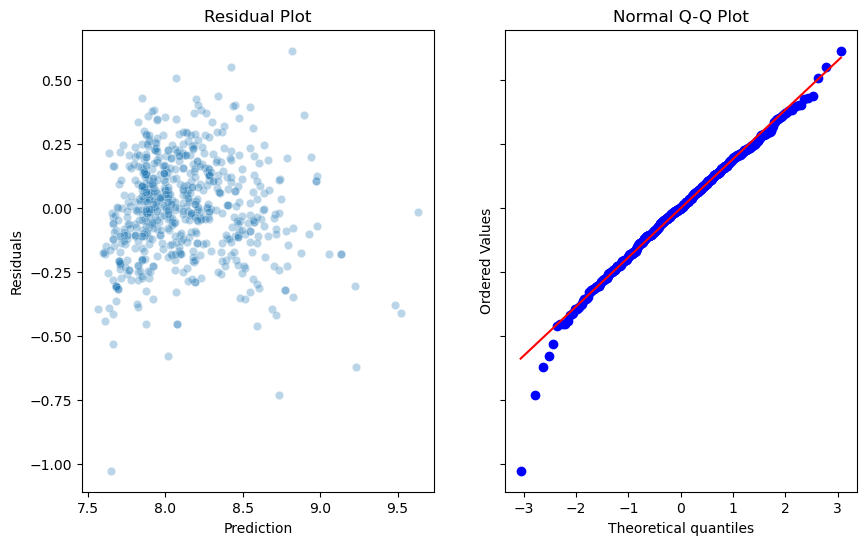

In [31]:
residual_analysis_plots(model)

## Final Model Fit & Test Scoring

In [32]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     766.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          6.01e-233
Time:                        21:49:06   Log-Likelihood:                 186.65
No. Observations:                 791   AIC:                            -365.3
Df Residuals:                     787   BIC:                            -346.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.4025      0.019    394.742      0.000       7.366       7.439
sqft           0.0005   2.59e-05     18.369      0.000       0.000       0.001
beds           0.0760      0.010      7.663      0.000       0.057       0.095
bath           0.0816      0.018      4.514      0.000       0.046       0.117
==============================================================================
Omnibus:                       30.719   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               62.710
Skew:                          -0.225   Prob(JB):                     2.41e-14
Kurtosis:                       4.304   Cond. No.                     3.66e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.66e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [33]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.675
Test MAE: 617.904
Test MSE: 910079.631


In [34]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.763, 0.675, 0.795, 0.767, 0.763]
R2:  0.752 +- 0.041
MAE: 542.167 +- 56.176
MSE: 745592.032 +- 294384.77


In [35]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     499.9
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.58e-193
Time:                        21:51:28   Log-Likelihood:                 168.35
No. Observations:                 633   AIC:                            -326.7
Df Residuals:                     628   BIC:                            -304.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4133      0.020    365.538      0.000       7.373       7.453
sqft                0.0005   2.83e-05     16.258      0.000       0.000       0.001
beds                0.0746      0.011      6.888      0.000       0.053       0.096
bath                0.0466      0.020      2.317      0.021       0.007       0.086
in_unit_laundry     0.1094      0.016      6.860      0.000       0.078       0.141
==============================================================================
Omnibus:                       37.219   Durbin-Watson:                   2.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               65.062
Skew:                          -0.409   Prob(JB):                     7.45e-15
Kurtosis:                       4.340   Cond. No.                     3.73e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.73e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

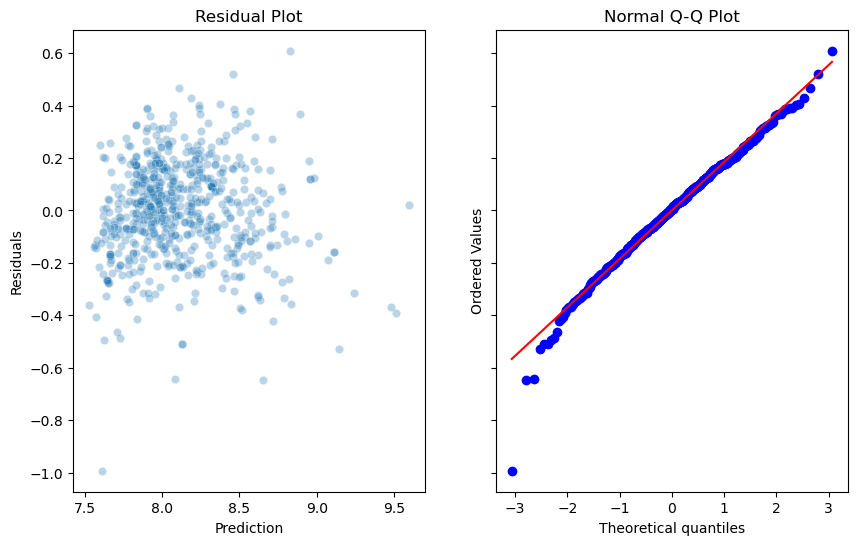

In [36]:
residual_analysis_plots(model)

In [37]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     628.2
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.62e-243
Time:                        21:52:16   Log-Likelihood:                 213.53
No. Observations:                 791   AIC:                            -417.1
Df Residuals:                     786   BIC:                            -393.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4019      0.018    408.095      0.000       7.366       7.438
sqft                0.0005   2.52e-05     18.339      0.000       0.000       0.001
beds                0.0788      0.010      8.210      0.000       0.060       0.098
bath                0.0517      0.018      2.883      0.004       0.017       0.087
in_unit_laundry     0.1058      0.014      7.436      0.000       0.078       0.134
==============================================================================
Omnibus:                       34.907   Durbin-Watson:                   1.974
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               76.818
Skew:                          -0.238   Prob(JB):                     2.08e-17
Kurtosis:                       4.451   Cond. No.                     3.71e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.71e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [38]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.723
Test MAE: 567.441
Test MSE: 776347.244


In [48]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'valet_x_sqft', 'valet_x_beds', 'valet_x_bath']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.77, 0.682, 0.801, 0.76, 0.788]
R2:  0.76 +- 0.042
MAE: 530.333 +- 45.845
MSE: 666466.965 +- 178330.008


In [49]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     293.8
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          5.80e-193
Time:                        21:58:02   Log-Likelihood:                 176.33
No. Observations:                 633   AIC:                            -336.7
Df Residuals:                     625   BIC:                            -301.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4236      0.020    364.489      0.000       7.384       7.464
sqft                0.0004    2.9e-05     15.258      0.000       0.000       0.000
beds                0.0830      0.011      7.488      0.000       0.061       0.105
bath                0.0397      0.020      1.979      0.048       0.000       0.079
in_unit_laundry     0.1052      0.016      6.643      0.000       0.074       0.136
valet_x_sqft        0.0001      0.000      0.531      0.596      -0.000       0.001
valet_x_beds        0.0690      0.174      0.396      0.692      -0.273       0.411
valet_x_bath       -0.0605      0.300     -0.202      0.840      -0.650       0.529
==============================================================================
Omnibus:                       38.030   Durbin-Watson:                   2.131
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.961
Skew:                          -0.410   Prob(JB):                     1.75e-15
Kurtosis:                       4.380   Cond. No.                     5.09e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.09e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

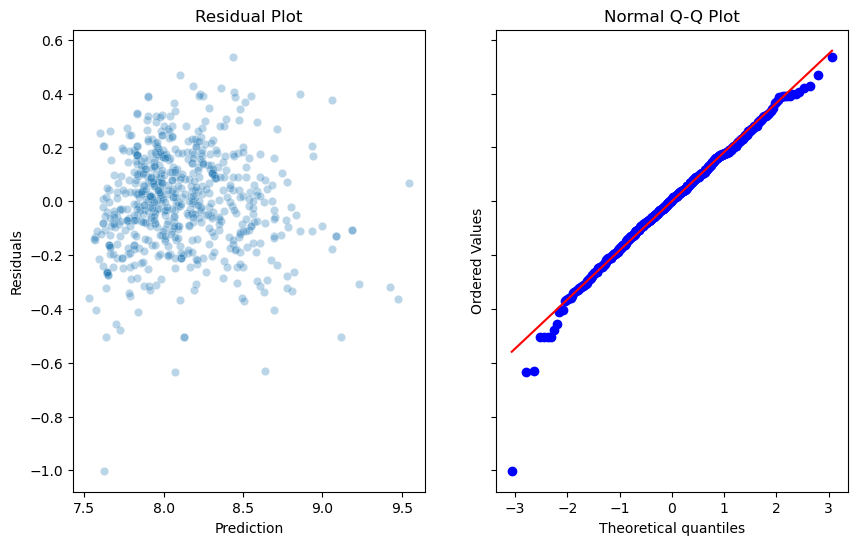

In [50]:
residual_analysis_plots(model)

In [51]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     379.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.13e-246
Time:                        21:58:04   Log-Likelihood:                 231.57
No. Observations:                 791   AIC:                            -447.1
Df Residuals:                     783   BIC:                            -409.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4197      0.018    409.892      0.000       7.384       7.455
sqft                0.0004   2.53e-05     17.490      0.000       0.000       0.000
beds                0.0889      0.010      9.187      0.000       0.070       0.108
bath                0.0365      0.018      2.052      0.041       0.002       0.071
in_unit_laundry     0.1011      0.014      7.228      0.000       0.074       0.129
valet_x_sqft    -9.106e-05      0.000     -0.429      0.668      -0.001       0.000
valet_x_beds       -0.0798      0.164     -0.486      0.627      -0.402       0.243
valet_x_bath        0.2571      0.271      0.948      0.343      -0.275       0.789
==============================================================================
Omnibus:                       33.862   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               58.015
Skew:                          -0.320   Prob(JB):                     2.52e-13
Kurtosis:                       4.163   Cond. No.                     5.23e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.23e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [52]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.739
Test MAE: 542.218
Test MSE: 639600.237


In [53]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'is_valet']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.768, 0.675, 0.808, 0.765, 0.779]
R2:  0.759 +- 0.044
MAE: 527.078 +- 51.995
MSE: 677262.196 +- 237676.438


In [54]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     410.9
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          3.93e-195
Time:                        22:04:57   Log-Likelihood:                 175.29
No. Observations:                 633   AIC:                            -338.6
Df Residuals:                     627   BIC:                            -311.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4166      0.020    369.075      0.000       7.377       7.456
sqft                0.0004   2.82e-05     15.964      0.000       0.000       0.001
beds                0.0803      0.011      7.416      0.000       0.059       0.102
bath                0.0436      0.020      2.185      0.029       0.004       0.083
in_unit_laundry     0.1026      0.016      6.455      0.000       0.071       0.134
is_valet            0.1597      0.043      3.729      0.000       0.076       0.244
==============================================================================
Omnibus:                       37.557   Durbin-Watson:                   2.131
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.869
Skew:                          -0.407   Prob(JB):                     3.02e-15
Kurtosis:                       4.369   Cond. No.                     6.41e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.41e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

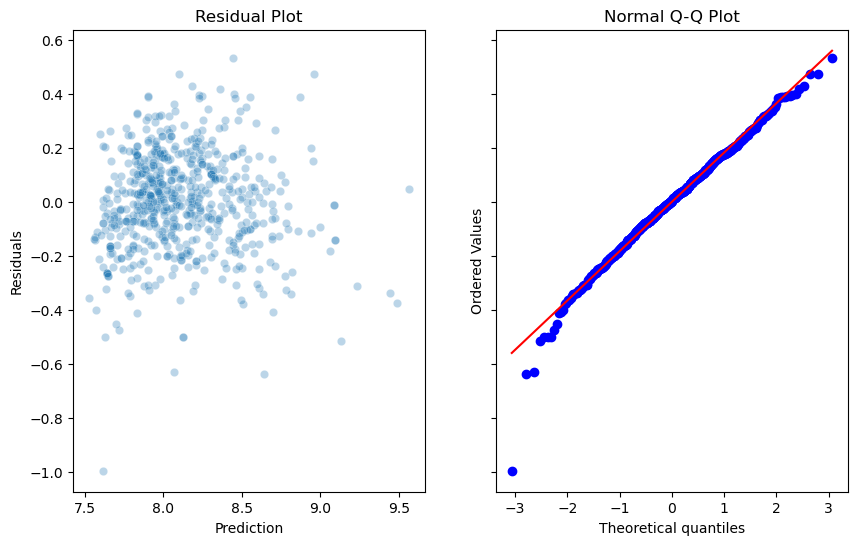

In [55]:
residual_analysis_plots(model)

In [56]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     523.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          3.94e-247
Time:                        22:05:50   Log-Likelihood:                 226.30
No. Observations:                 791   AIC:                            -440.6
Df Residuals:                     785   BIC:                            -412.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4082      0.018    413.826      0.000       7.373       7.443
sqft                0.0005   2.48e-05     18.159      0.000       0.000       0.000
beds                0.0852      0.010      8.932      0.000       0.066       0.104
bath                0.0450      0.018      2.541      0.011       0.010       0.080
in_unit_laundry     0.0978      0.014      6.935      0.000       0.070       0.126
is_valet            0.1927      0.038      5.074      0.000       0.118       0.267
==============================================================================
Omnibus:                       33.402   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               62.653
Skew:                          -0.284   Prob(JB):                     2.48e-14
Kurtosis:                       4.256   Cond. No.                     6.37e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.37e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [57]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.738
Test MAE: 543.425
Test MSE: 678053.896


In [58]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'is_valet', 'has_parking']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.782, 0.678, 0.814, 0.789, 0.78]
R2:  0.769 +- 0.047
MAE: 511.98 +- 52.495
MSE: 656918.424 +- 250464.934


In [59]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     368.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.16e-201
Time:                        22:14:36   Log-Likelihood:                 193.62
No. Observations:                 633   AIC:                            -373.2
Df Residuals:                     626   BIC:                            -342.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.3932      0.020    371.338      0.000       7.354       7.432
sqft                0.0004   2.78e-05     15.182      0.000       0.000       0.000
beds                0.0942      0.011      8.746      0.000       0.073       0.115
bath                0.0361      0.019      1.859      0.064      -0.002       0.074
in_unit_laundry     0.0829      0.016      5.255      0.000       0.052       0.114
is_valet            0.1316      0.042      3.142      0.002       0.049       0.214
has_parking         0.0939      0.015      6.110      0.000       0.064       0.124
==============================================================================
Omnibus:                       38.461   Durbin-Watson:                   2.058
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               75.497
Skew:                          -0.383   Prob(JB):                     4.04e-17
Kurtosis:                       4.508   Cond. No.                     6.45e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.45e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

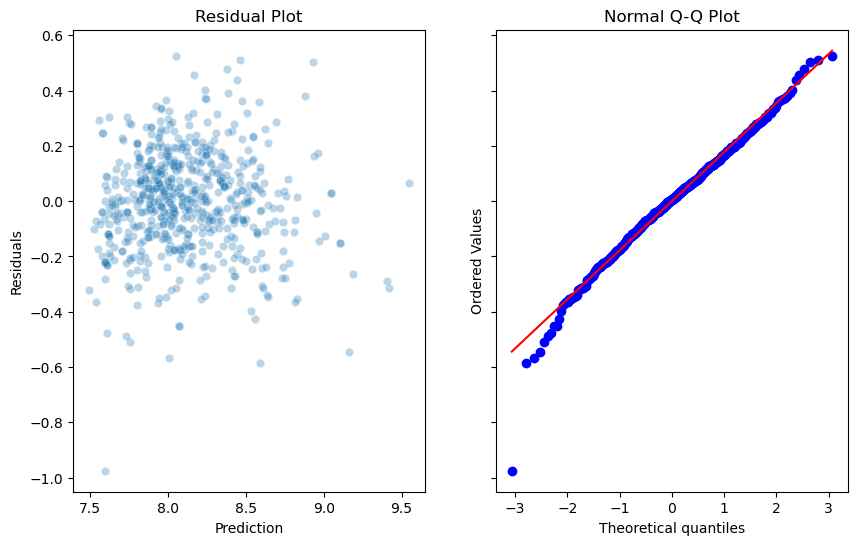

In [60]:
residual_analysis_plots(model)

In [61]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     463.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          6.96e-254
Time:                        22:15:32   Log-Likelihood:                 245.22
No. Observations:                 791   AIC:                            -476.4
Df Residuals:                     784   BIC:                            -443.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.3880      0.018    415.309      0.000       7.353       7.423
sqft                0.0004   2.46e-05     17.422      0.000       0.000       0.000
beds                0.0971      0.010     10.207      0.000       0.078       0.116
bath                0.0363      0.017      2.092      0.037       0.002       0.070
in_unit_laundry     0.0794      0.014      5.628      0.000       0.052       0.107
is_valet            0.1691      0.037      4.532      0.000       0.096       0.242
has_parking         0.0851      0.014      6.199      0.000       0.058       0.112
==============================================================================
Omnibus:                       33.982   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               73.075
Skew:                          -0.238   Prob(JB):                     1.35e-16
Kurtosis:                       4.411   Cond. No.                     6.41e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.41e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [62]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.744
Test MAE: 540.678
Test MSE: 670715.163


In [63]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'is_valet', 'has_parking', 'is_single']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.786, 0.68, 0.818, 0.79, 0.785]
R2:  0.772 +- 0.048
MAE: 510.246 +- 48.579
MSE: 640624.5 +- 236773.678


In [64]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.782
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     320.1
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          6.25e-202
Time:                        22:19:11   Log-Likelihood:                 197.30
No. Observations:                 633   AIC:                            -378.6
Df Residuals:                     625   BIC:                            -343.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.3916      0.020    372.938      0.000       7.353       7.430
sqft                0.0004   2.83e-05     15.484      0.000       0.000       0.000
beds                0.0952      0.011      8.874      0.000       0.074       0.116
bath                0.0280      0.020      1.431      0.153      -0.010       0.066
in_unit_laundry     0.0821      0.016      5.226      0.000       0.051       0.113
is_valet            0.1258      0.042      3.015      0.003       0.044       0.208
has_parking         0.0947      0.015      6.194      0.000       0.065       0.125
is_single          -0.0994      0.037     -2.700      0.007      -0.172      -0.027
==============================================================================
Omnibus:                       34.592   Durbin-Watson:                   2.065
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               65.709
Skew:                          -0.355   Prob(JB):                     5.39e-15
Kurtosis:                       4.410   Cond. No.                     6.48e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.48e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

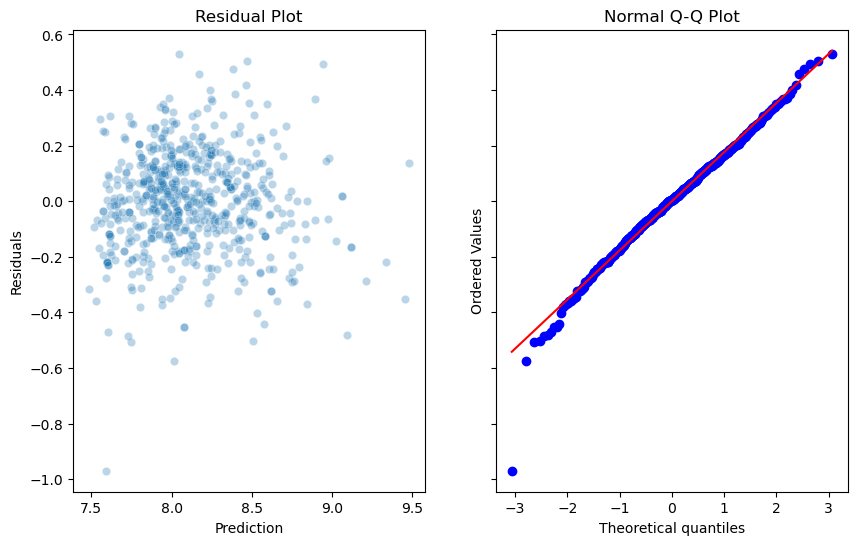

In [65]:
residual_analysis_plots(model)

In [66]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.781
Method:                 Least Squares   F-statistic:                     404.0
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          6.47e-255
Time:                        22:19:59   Log-Likelihood:                 250.78
No. Observations:                 791   AIC:                            -485.6
Df Residuals:                     783   BIC:                            -448.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.3846      0.018    417.074      0.000       7.350       7.419
sqft                0.0004   2.48e-05     17.845      0.000       0.000       0.000
beds                0.0987      0.009     10.431      0.000       0.080       0.117
bath                0.0300      0.017      1.729      0.084      -0.004       0.064
in_unit_laundry     0.0787      0.014      5.620      0.000       0.051       0.106
is_valet            0.1627      0.037      4.384      0.000       0.090       0.236
has_parking         0.0862      0.014      6.324      0.000       0.059       0.113
is_single          -0.1077      0.032     -3.327      0.001      -0.171      -0.044
==============================================================================
Omnibus:                       30.526   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               63.699
Skew:                          -0.214   Prob(JB):                     1.47e-14
Kurtosis:                       4.323   Cond. No.                     6.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [67]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.749
Test MAE: 531.996
Test MSE: 639103.845


In [74]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'is_valet', 'has_parking', 'is_single', 'is_double']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.785, 0.686, 0.82, 0.789, 0.787]
R2:  0.773 +- 0.046
MAE: 508.896 +- 48.304
MSE: 638507.727 +- 236743.785


In [73]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.780
Method:                 Least Squares   F-statistic:                     322.0
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.47e-202
Time:                        22:27:07   Log-Likelihood:                 198.76
No. Observations:                 633   AIC:                            -381.5
Df Residuals:                     625   BIC:                            -345.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.4110      0.017    430.742      0.000       7.377       7.445
sqft                0.0005   2.51e-05     18.106      0.000       0.000       0.001
beds                0.0977      0.011      9.240      0.000       0.077       0.118
in_unit_laundry     0.0855      0.015      5.559      0.000       0.055       0.116
is_valet            0.1279      0.042      3.073      0.002       0.046       0.210
has_parking         0.0934      0.015      6.118      0.000       0.063       0.123
is_single          -0.1078      0.036     -2.969      0.003      -0.179      -0.036
is_double          -0.1638      0.074     -2.228      0.026      -0.308      -0.019
==============================================================================
Omnibus:                       34.655   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               69.945
Skew:                          -0.335   Prob(JB):                     6.48e-16
Kurtosis:                       4.485   Cond. No.                     1.14e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.14e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

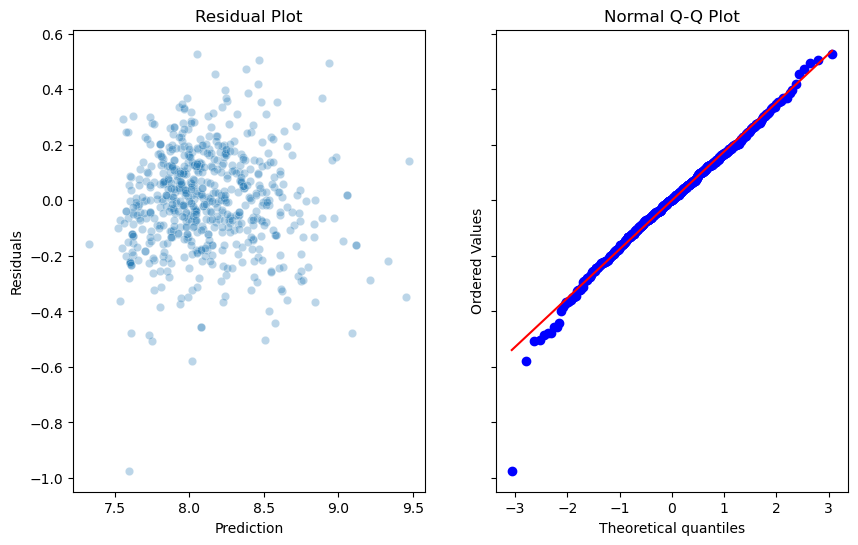

In [75]:
residual_analysis_plots(model)

In [76]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     356.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          5.89e-255
Time:                        22:28:24   Log-Likelihood:                 253.95
No. Observations:                 791   AIC:                            -489.9
Df Residuals:                     782   BIC:                            -447.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.3906      0.018    415.084      0.000       7.356       7.426
sqft                0.0004   2.47e-05     17.720      0.000       0.000       0.000
beds                0.0994      0.009     10.533      0.000       0.081       0.118
bath                0.0302      0.017      1.746      0.081      -0.004       0.064
in_unit_laundry     0.0776      0.014      5.551      0.000       0.050       0.105
is_valet            0.1638      0.037      4.426      0.000       0.091       0.236
has_parking         0.0835      0.014      6.124      0.000       0.057       0.110
is_single          -0.1077      0.032     -3.339      0.001      -0.171      -0.044
is_double          -0.1501      0.060     -2.510      0.012      -0.268      -0.033
==============================================================================
Omnibus:                       32.807   Durbin-Watson:                   1.950
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               71.121
Skew:                          -0.222   Prob(JB):                     3.60e-16
Kurtosis:                       4.400   Cond. No.                     1.03e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.03e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [77]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.757
Test MAE: 524.437
Test MSE: 628599.272


In [83]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'is_valet', 'has_parking', 'is_single', 'is_double', 'district_zone_east', 'district_zone_north', 'district_zone_south',	'district_zone_west']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.805, 0.733, 0.854, 0.819, 0.794]
R2:  0.801 +- 0.04
MAE: 482.779 +- 38.122
MSE: 593903.684 +- 226270.702


In [84]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     230.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          3.17e-219
Time:                        22:34:16   Log-Likelihood:                 252.43
No. Observations:                 633   AIC:                            -478.9
Df Residuals:                     620   BIC:                            -421.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.4266      0.023    324.287      0.000       7.382       7.472
sqft                    0.0004   2.63e-05     15.592      0.000       0.000       0.000
beds                    0.0971      0.010      9.768      0.000       0.078       0.117
bath                    0.0474      0.018      2.613      0.009       0.012       0.083
in_unit_laundry         0.0794      0.015      5.213      0.000       0.049       0.109
is_valet                0.1183      0.039      3.061      0.002       0.042       0.194
has_parking             0.0979      0.014      6.889      0.000       0.070       0.126
is_single              -0.0102      0.036     -0.287      0.774      -0.080       0.060
is_double              -0.0545      0.069     -0.786      0.432      -0.191       0.082
district_zone_east     -0.0364      0.020     -1.850      0.065      -0.075       0.002
district_zone_north    -0.0106      0.019     -0.556      0.578      -0.048       0.027
district_zone_south    -0.3773      0.039     -9.723      0.000      -0.454      -0.301
district_zone_west     -0.1208      0.027     -4.499      0.000      -0.174      -0.068
==============================================================================
Omnibus:                        6.921   Durbin-Watson:                   2.039
Prob(Omnibus):                  0.031   Jarque-Bera (JB):                9.880
Skew:                           0.001   Prob(JB):                      0.00715
Kurtosis:                       3.612   Cond. No.                     1.17e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.17e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

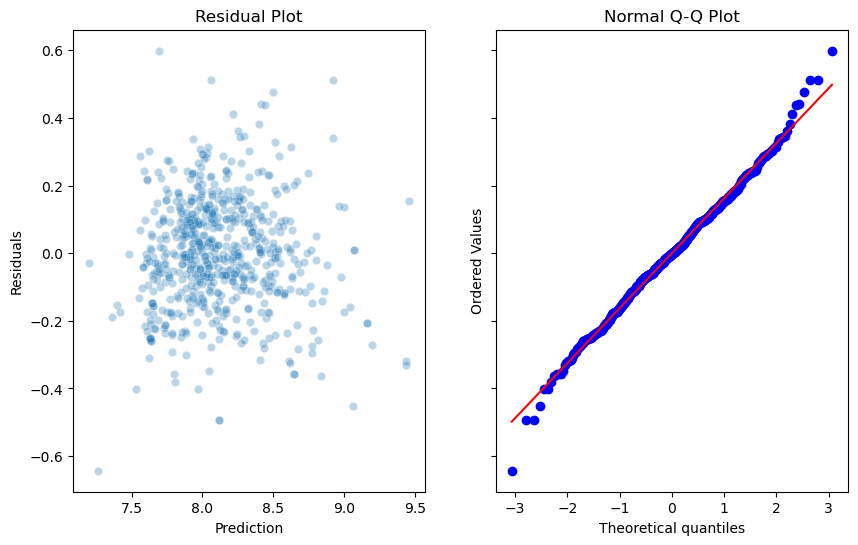

In [85]:
residual_analysis_plots(model)

In [86]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     282.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          7.06e-274
Time:                        22:34:17   Log-Likelihood:                 310.15
No. Observations:                 791   AIC:                            -594.3
Df Residuals:                     778   BIC:                            -533.5
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.4295      0.021    358.554      0.000       7.389       7.470
sqft                    0.0004   2.33e-05     17.961      0.000       0.000       0.000
beds                    0.0987      0.009     11.103      0.000       0.081       0.116
bath                    0.0434      0.016      2.672      0.008       0.012       0.075
in_unit_laundry         0.0782      0.014      5.616      0.000       0.051       0.105
is_valet                0.1587      0.035      4.557      0.000       0.090       0.227
has_parking             0.0845      0.013      6.579      0.000       0.059       0.110
is_single              -0.0204      0.032     -0.646      0.519      -0.082       0.042
is_double              -0.0660      0.057     -1.149      0.251      -0.179       0.047
district_zone_east     -0.0383      0.018     -2.144      0.032      -0.073      -0.003
district_zone_north    -0.0141      0.017     -0.819      0.413      -0.048       0.020
district_zone_south    -0.3484      0.035    -10.042      0.000      -0.417      -0.280
district_zone_west     -0.1106      0.023     -4.768      0.000      -0.156      -0.065
==============================================================================
Omnibus:                       12.350   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               20.206
Skew:                           0.061   Prob(JB):                     4.09e-05
Kurtosis:                       3.773   Cond. No.                     1.07e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.07e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [87]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.769
Test MAE: 520.786
Test MSE: 636341.628


In [88]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'is_valet', 'has_parking',  'district_zone_east', 'district_zone_south',	'district_zone_west']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.807, 0.732, 0.854, 0.821, 0.793]
R2:  0.801 +- 0.04
MAE: 482.271 +- 39.385
MSE: 595733.552 +- 229038.615


In [89]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     308.0
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.01e-222
Time:                        22:34:34   Log-Likelihood:                 251.95
No. Observations:                 633   AIC:                            -483.9
Df Residuals:                     623   BIC:                            -439.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.4185      0.019    394.930      0.000       7.382       7.455
sqft                    0.0004   2.55e-05     15.992      0.000       0.000       0.000
beds                    0.0977      0.010      9.905      0.000       0.078       0.117
bath                    0.0483      0.018      2.710      0.007       0.013       0.083
in_unit_laundry         0.0800      0.015      5.287      0.000       0.050       0.110
is_valet                0.1174      0.039      3.048      0.002       0.042       0.193
has_parking             0.0986      0.014      6.972      0.000       0.071       0.126
district_zone_east     -0.0297      0.015     -1.937      0.053      -0.060       0.000
district_zone_south    -0.3747      0.036    -10.346      0.000      -0.446      -0.304
district_zone_west     -0.1188      0.023     -5.267      0.000      -0.163      -0.075
==============================================================================
Omnibus:                        6.435   Durbin-Watson:                   2.037
Prob(Omnibus):                  0.040   Jarque-Bera (JB):                8.961
Skew:                          -0.004   Prob(JB):                       0.0113
Kurtosis:                       3.583   Cond. No.                     6.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

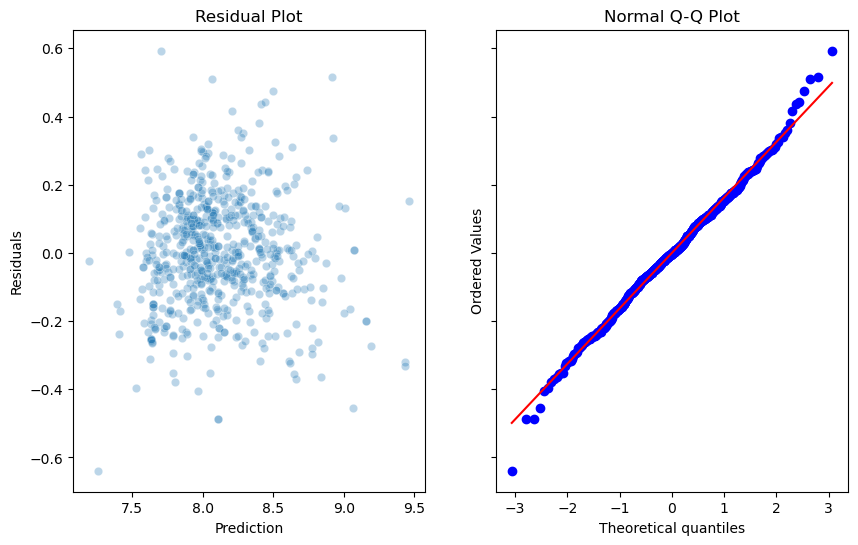

In [90]:
residual_analysis_plots(model)

In [91]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.813
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     376.9
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          3.21e-277
Time:                        22:35:15   Log-Likelihood:                 309.00
No. Observations:                 791   AIC:                            -598.0
Df Residuals:                     781   BIC:                            -551.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.4194      0.017    436.373      0.000       7.386       7.453
sqft                    0.0004   2.28e-05     18.245      0.000       0.000       0.000
beds                    0.0992      0.009     11.259      0.000       0.082       0.116
bath                    0.0445      0.016      2.761      0.006       0.013       0.076
in_unit_laundry         0.0788      0.014      5.691      0.000       0.052       0.106
is_valet                0.1578      0.035      4.541      0.000       0.090       0.226
has_parking             0.0854      0.013      6.678      0.000       0.060       0.110
district_zone_east     -0.0295      0.014     -2.087      0.037      -0.057      -0.002
district_zone_south    -0.3458      0.032    -10.695      0.000      -0.409      -0.282
district_zone_west     -0.1094      0.019     -5.663      0.000      -0.147      -0.071
==============================================================================
Omnibus:                       11.415   Durbin-Watson:                   1.970
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               18.213
Skew:                           0.055   Prob(JB):                     0.000111
Kurtosis:                       3.735   Cond. No.                     6.47e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.47e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [92]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.766
Test MAE: 524.302
Test MSE: 642140.079


In [93]:
features = ['sqft', 'beds', 'bath', 'in_unit_laundry', 'is_valet', 'has_parking', 'district_zone_south', 'district_zone_west']
X_train, X_test, y_train, y_test = split_data(rentals_df, features)
model = cv(X_train, y_train)

Training Set Rows: 989 Test Set Rows: 198
All Validation R2:   [0.805, 0.729, 0.855, 0.819, 0.792]
R2:  0.8 +- 0.041
MAE: 485.373 +- 39.817
MSE: 599244.268 +- 225884.591


In [94]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     344.5
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          3.42e-223
Time:                        22:47:30   Log-Likelihood:                 250.05
No. Observations:                 633   AIC:                            -482.1
Df Residuals:                     624   BIC:                            -442.0
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.4108      0.018    402.591      0.000       7.375       7.447
sqft                    0.0004   2.55e-05     16.160      0.000       0.000       0.000
beds                    0.0982      0.010      9.938      0.000       0.079       0.118
bath                    0.0462      0.018      2.595      0.010       0.011       0.081
in_unit_laundry         0.0730      0.015      4.956      0.000       0.044       0.102
is_valet                0.1102      0.038      2.868      0.004       0.035       0.186
has_parking             0.0954      0.014      6.776      0.000       0.068       0.123
district_zone_south    -0.3630      0.036    -10.143      0.000      -0.433      -0.293
district_zone_west     -0.1102      0.022     -4.972      0.000      -0.154      -0.067
==============================================================================
Omnibus:                        5.622   Durbin-Watson:                   2.047
Prob(Omnibus):                  0.060   Jarque-Bera (JB):                7.480
Skew:                          -0.013   Prob(JB):                       0.0237
Kurtosis:                       3.532   Cond. No.                     6.49e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.49e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

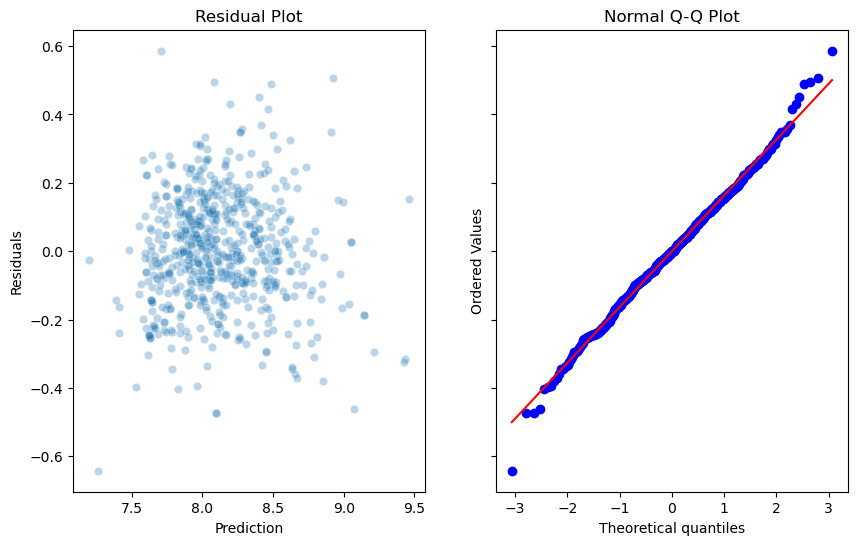

In [95]:
residual_analysis_plots(model)

In [96]:
model = model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     421.6
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.32e-277
Time:                        22:48:20   Log-Likelihood:                 306.80
No. Observations:                 791   AIC:                            -595.6
Df Residuals:                     782   BIC:                            -553.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   7.4125      0.017    443.341      0.000       7.380       7.445
sqft                    0.0004   2.28e-05     18.499      0.000       0.000       0.000
beds                    0.0998      0.009     11.315      0.000       0.083       0.117
bath                    0.0415      0.016      2.582      0.010       0.010       0.073
in_unit_laundry         0.0712      0.013      5.319      0.000       0.045       0.098
is_valet                0.1496      0.035      4.324      0.000       0.082       0.218
has_parking             0.0821      0.013      6.459      0.000       0.057       0.107
district_zone_south    -0.3342      0.032    -10.470      0.000      -0.397      -0.272
district_zone_west     -0.1013      0.019     -5.342      0.000      -0.139      -0.064
==============================================================================
Omnibus:                       10.217   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               15.718
Skew:                           0.049   Prob(JB):                     0.000386
Kurtosis:                       3.684   Cond. No.                     6.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [97]:
test_preds = model.predict(X_test)

print(f'Test R2:  {round(r2(y_test, test_preds), 3)}')
print(f'Test MAE: {round(mae(np.exp(y_test), np.exp(test_preds)), 3)}')
print(f'Test MSE: {round(mse(np.exp(y_test), np.exp(test_preds)), 3)}')

Test R2:  0.769
Test MAE: 522.973
Test MSE: 636297.171
